#BIO 라벨링

{
  "tokens": ["너랑", "같이", "자", "고", "싶", "어"],
  "labels": ["O", "O", "B-RISK", "I-RISK", "I-RISK", "I-RISK"]
}

라벨은 보통 다음 중 하나:

- O (기타)

- B-RISK (위험 단어 시작)

- I-RISK (위험 단어 내부)

## 전체 데이터 형식

```
data = [
    {
        "tokens": ["사진만", "하나", "보내줘", "."],
        "labels": [1, 2, 2, 0],  # B-RISK, I-RISK, I-RISK, O
    },
    {
        "tokens": ["어른들이", "몰라도", "돼", "."],
        "labels": [1, 2, 2, 0],
    },
]
```

## 처리 전략

- 위험 단어 사전 포함 -> source = "keyword"

- 미포함 + 의미 기반 위험 -> source = "semantic"

### Step 0. 워드 클라우드

In [ ]:
from google.colab import files

files.upload()

Saving sum.csv to sum.csv


{'sum.csv': b'text,,,,,\r\n\xb3\xaa \xba\xb8\xb0\xed \xbd\xcd\xbe\xfa\xbe\xee?,,,,,\r\n\xb1\xd7 \xbb\xe7\xc1\xf8 \xbb\xf5\xb7\xce \xc2\xef\xc0\xba \xb0\xc5\xbe\xdf?,,,,,\r\n\xc1\xbb \xb4\xf5 \xc7\xd6\xc7\xd1 \xbb\xe7\xc1\xf8 \xc0\xd6\xc0\xb8\xb8\xe9 \xc1\xc1\xb0\xda\xbe\xee.,,,,,\r\n\xb1\xd7\xb7\xa1\xb5\xb5 \xc1\xc1\xc0\xba \xbb\xe7\xc1\xf8\xc0\xcc\xbe\xfa\xbe\xee.,,,,,\r\n\xbf\xc0 \xb1\xd7\xb7\xb8\xb1\xb8\xb3\xaa \xb3\xca \xb4\xd9\xc1\xa4\xc7\xcf\xb4\xd9,,,,,\r\n\xb1\xd7 \xbd\xc3\xb0\xa3 \xb1\xa6\xc2\xfa\xbe\xc6?,,,,,\r\n\xb1\xe2\xb1\xb8 \xbd\xe1\xba\xc3\xbe\xee ? ,,,,,\r\n\xbf\xc0\xc0\xcf \xc1\xc1\xbe\xc6\xc7\xd8?,,,,,\r\n\xb6\xc7 \xb9\xb9 \xc1\xc1\xbe\xc6\xc7\xd8?,,,,,\r\n"\xbf\xc0, \xb1\xa6\xc2\xfa\xbe\xc6.",,,,,\r\n\xb1\xd7\xb7\xa1\xbc\xad \xba\xce\xb2\xf4\xb7\xaf\xbf\xf6?,,,,,\r\n\xb3\xbb\xb0\xa1 \xb8\xd5\xc0\xfa \xc7\xd8\xba\xbc\xb1\xee? \xbe\xc6\xb4\xcf\xb8\xe9 \xb3\xd7\xb0\xa1 \xb3\xaa\xc7\xd1\xc5\xd7 \xc7\xd8\xba\xbc\xb7\xa1?,,,,,\r\n\xbe\xee\xb6\xb2 \xbd\xba\xc5\xb8\xc0\xcf 

In [ ]:
import pandas as pd

df = pd.read_csv("/content/sum.csv", encoding = 'cp949')
df.head()

,text,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,나 보고 싶었어?,NaN,NaN,NaN,NaN,NaN
1,그 사진 새로 찍은 거야?,NaN,NaN,NaN,NaN,NaN
2,좀 더 핫한 사진 있으면 좋겠어.,NaN,NaN,NaN,NaN,NaN
3,그래도 좋은 사진이었어.,NaN,NaN,NaN,NaN,NaN
4,오 그렇구나 너 다정하다,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.drop(columns=['Unnamed: 1','Unnamed: 2','Unnamed: 3','Unnamed: 4','Unnamed: 5'], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7239 entries, 0 to 7238
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    7239 non-null   object
dtypes: object(1)
memory usage: 56.7+ KB


In [ ]:
num_splits = 10
rows_per_file = len(df) // num_splits  # 몫

for i in range(num_splits):
    start_idx = i * rows_per_file
    # 마지막 파일은 남은 행 모두 포함
    if i == num_splits - 1:
        end_idx = len(df)
    else:
        end_idx = (i + 1) * rows_per_file

    df_part = df.iloc[start_idx:end_idx]
    df_part.to_csv(f'df_part_{i+1}.csv', index=False)


#### 워드 클라우드

In [ ]:
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.1/494.1 kB 29.0 MB/s eta 0:00:00


In [ ]:
from konlpy.tag import Okt
from collections import Counter

# 형태소 분석기 초기화
okt = Okt()

# 전체 구(Phrase) 리스트
all_phrases = []

# 각 문장에서 의미 단위 구(Phrase) 추출
for text in df['text']:
    phrases = okt.phrases(text)
    all_phrases.extend(phrases)

# 빈도수 계산
phrase_counts = Counter(all_phrases)

# 상위 100개 출력
top_100 = phrase_counts.most_common(100)

# 결과 출력
print("상위 100개 구(Phrase):")
for phrase, count in top_100:
    print(f"{phrase}: {count}")


상위 100개 구(Phrase):
진짜: 263
보고: 224
사진: 198
생각: 164
우리: 159
키스: 121
지금: 120
그냥: 110
사랑: 106
엄마: 105
오늘: 103
얘기: 99
남자: 86
거기: 82
자기야: 68
섹스: 65
팬티: 63
거지: 61
사람: 60
혼자: 60
가슴: 59
오늘 밤: 58
어디: 56
엉덩이: 56
주소: 55
언제: 55
기분: 54
여자: 54
전화: 52
얼마나: 49
시간: 48
아빠: 48
여기: 48
다른: 47
완전: 46
수도: 44
내일: 42
나이: 42
만날: 40
알몸: 37
주말: 36
친구: 36
너 진짜: 35
손가락: 35
침대: 32
브라: 32
시기: 32
자고: 31
처음: 31
만지고: 30
번호: 30
흥분: 29
목소리: 28
사정: 28
속옷: 28
이번: 27
정말: 27
무슨: 27
다시: 26
콘돔: 26
다음: 26
부모님: 26
오케이: 24
계속: 24
하루: 23
마음: 23
해도: 23
진짜 보고: 22
서로: 22
자위: 22
살짝: 21
지금 뭐: 21
얼굴: 21
느낌: 21
대해: 20
상상: 20
정도: 20
치마: 20
위해: 20
젖꼭지: 19
항상: 19
걱정: 19
샤워: 19
모습: 19
때문: 19
자주: 18
준비: 18
제일: 18
살이: 18
13: 18
내 거시기: 18
가까이: 17
가지: 17
학교: 17
그거: 17
몰래: 17
제대로: 17
절대: 17
잠옷: 17
웹캠: 17


Selecting previously unselected package fonts-nanum.
(Reading database ... 126111 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50892 (\N{HANGUL SYLLABLE WEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

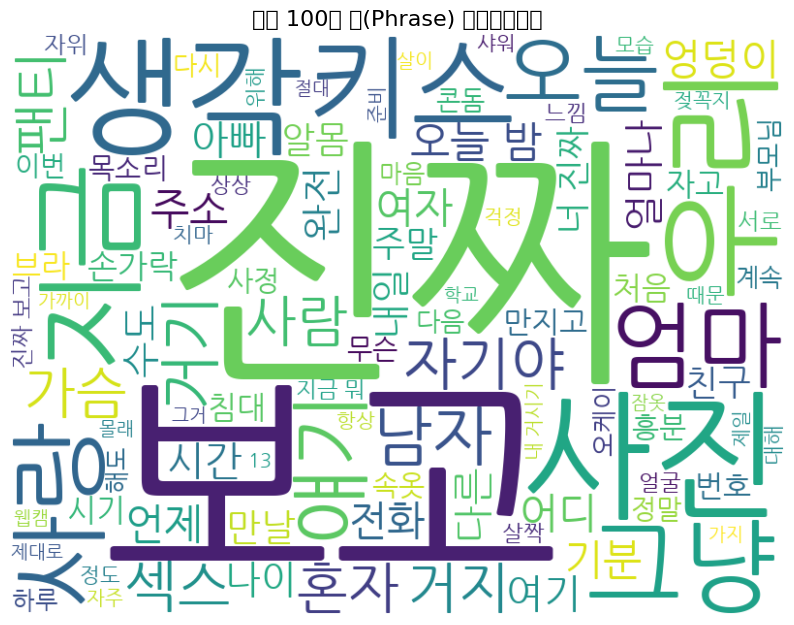

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. 나눔고딕 폰트 설치
!apt-get -qq install fonts-nanum

# 2. WordCloud에 폰트 경로 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

# 예: phrase_counts.most_common(100) 리턴값
top_100_list = phrase_counts.most_common(100)

# 워드클라우드 생성
wordcloud = WordCloud(
    font_path='NanumGothic.ttf',  # 경로만 잘 지정되면 OK
    background_color='white',
    width=800,
    height=600
).generate_from_frequencies(dict(top_100_list))  # 여기서 바로 dict 변환

# 시각화
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("상위 100개 구(Phrase) 워드클라우드", fontsize=16)
plt.show()


### Step 1. datasets.Dataset 생성

In [1]:
from google.colab import files

files.upload()

Saving sample_token_label_data.json to sample_token_label_data.json


{'sample_token_label_data.json': b'[\n  {\n    "tokens": [\n      "\xec\x95\x88\xeb\x85\x95",\n      "\xed\x95\x98\xec\x84\xb8\xec\x9a\x94"\n    ],\n    "labels": [\n      0,\n      0\n    ]\n  },\n   {\n    "tokens": [\n      "\xec\xa7\x80\xea\xb8\x88",\n      "\xeb\x8b\xb9\xec\x9e\xa5",\n      "\xeb\x84\x88\xed\x95\x9c\xed\x85\x8c",\n      "\xea\xb0\x80\xea\xb3\xa0",\n      "\xec\x8b\xb6\xeb\x8b\xa4",\n      "."\n    ],\n    "labels": [\n      0,\n      0,\n      0,\n      1,\n      2,\n      0\n    ]\n  },\n  {\n    "tokens": [\n      "\xec\xa2\x80",\n      "\xec\x97\x90\xeb\xa1\x9c\xed\x8b\xb1\xed\x95\x9c",\n      "\xea\xbf\x88\xec\x9d\xb4\xec\x97\x88\xeb\x8a\x94\xeb\x8d\xb0",\n      "\xeb\x82\x98\xeb\x8f\x84",\n      "\xec\xa2\x80",\n      "\xeb\x86\x80\xeb\x9e\x90\xec\x9d\x8c"\n    ],\n    "labels": [\n      0,\n      1,\n      2,\n      0,\n      0,\n      0\n    ]\n  },\n  {\n    "tokens": [\n      "\xec\x9e\xa0\xec\x98\xb7\xec\x97\x90",\n      "\xed\x85\x90\xed\x8a\xb8",\n    

In [2]:
from datasets import Dataset
import json

# JSON 파일 불러오기
with open("/content/sample_token_label_data.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Hugging Face Dataset으로 변환
dataset = Dataset.from_list(data)

In [3]:
data

[{'tokens': ['안녕', '하세요'], 'labels': [0, 0]},
 {'tokens': ['지금', '당장', '너한테', '가고', '싶다', '.'],
  'labels': [0, 0, 0, 1, 2, 0]},
 {'tokens': ['좀', '에로틱한', '꿈이었는데', '나도', '좀', '놀랐음'],
  'labels': [0, 1, 2, 0, 0, 0]},
 {'tokens': ['잠옷에', '텐트', '쳐져', '있었음', 'ㅋㅋ'], 'labels': [1, 2, 2, 2, 0]}]

In [4]:
len(data)

4

### Step 2. 토크나이저 및 모델 준비

In [5]:
from transformers import BertForTokenClassification, BertTokenizerFast

model = BertForTokenClassification.from_pretrained("klue/bert-base", num_labels=3)
tokenizer = BertTokenizerFast.from_pretrained("klue/bert-base")  # O, B, I

# label mapping 추가
label_list = ["O", "B", "I"]
model.config.id2label = {i: l for i, l in enumerate(label_list)}
model.config.label2id = {l: i for i, l in enumerate(label_list)}

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

### Step 3. 전처리 함수 (Tokenize + Label 정렬)

In [6]:
def tokenize_and_align_labels(examples):
    tokenized = tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        padding="max_length",
        truncation=True,
        max_length=32,
        return_offsets_mapping=True,
        return_token_type_ids=True,  # 추가
    )
    all_labels = []
    for i in range(len(examples["tokens"])):
        word_ids = tokenized.word_ids(batch_index=i)
        label_ids = []
        prev_word_idx = None
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != prev_word_idx:
                label_ids.append(examples["labels"][i][word_idx])
            else:
                label_ids.append(examples["labels"][i][word_idx])
            prev_word_idx = word_idx
        all_labels.append(label_ids)
    tokenized["labels"] = all_labels
    return tokenized

### Step 4. 데이터 전처리 적용

In [7]:
tokenized_dataset = dataset.map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/4 [00:00<?, ? examples/s]

### Step 5. 학습 설정

In [51]:
!pip uninstall -y torch torchvision torchaudio transformers
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install transformers

In [8]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./outputs",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    num_train_epochs=3,
    logging_dir="./logs",
    save_strategy="epoch"
)

### Step 6. Trainer로 학습

In [9]:
all_labels = []
for example_labels in tokenized_dataset["labels"]:
    all_labels.extend([l for l in example_labels if l != -100])
print("labels max:", max(all_labels))
print("labels min:", min(all_labels))

labels max: 2
labels min: 0


In [10]:
print("model.config.num_labels:", model.config.num_labels)
print("model.config.id2label:", model.config.id2label)

model.config.num_labels: 3
model.config.id2label: {0: 'O', 1: 'B', 2: 'I'}


In [11]:
print(model.config.num_labels)

3


In [12]:
# model.config.num_labels를 먼저 확인
print("✅ num_labels =", model.config.num_labels)

# tokenized_dataset 전체에서 라벨이 유효 범위 안에 있는지 확인
all_labels = []
for example in tokenized_dataset:
    for l in example["labels"]:
        if l != -100:
            all_labels.append(l)

print("✅ 라벨 최솟값:", min(all_labels))
print("✅ 라벨 최댓값:", max(all_labels))

# 유효하지 않은 라벨 있으면 출력
invalid_labels = [l for l in all_labels if l < 0 or l >= model.config.num_labels]
print("🚨 잘못된 라벨 수:", len(invalid_labels))
print("🚨 잘못된 라벨 목록 (중복 제거):", set(invalid_labels))


✅ num_labels = 3
✅ 라벨 최솟값: 0
✅ 라벨 최댓값: 2
🚨 잘못된 라벨 수: 0
🚨 잘못된 라벨 목록 (중복 제거): set()


In [13]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer,
    padding="max_length",          # 길이 통일
    max_length=32,                 # 명시적 길이 고정
    return_tensors="pt"            # 텐서 형식 고정
)


In [14]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    eval_dataset=tokenized_dataset,
    data_collator=data_collator,
)
trainer.train()


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: seongmin2053 (seongmin2053-dong-eui-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss
1,No log,0.669666
2,No log,0.450522
3,No log,0.359306


TrainOutput(global_step=3, training_loss=0.8304818471272787, metrics={'train_runtime': 63.4622, 'train_samples_per_second': 0.189, 'train_steps_per_second': 0.047, 'total_flos': 195974339328.0, 'train_loss': 0.8304818471272787, 'epoch': 3.0})

### Step 7. 모델 저장

In [ ]:
# 모델 저장
trainer.save_model("./my-model")  # 원하는 경로에 저장
tokenizer.save_pretrained("./my-model")  # 토크나이저도 함께 저장

### Step 8. 예측 테스트

In [23]:
from transformers import AutoTokenizer, AutoModelForTokenClassification
import torch

text = "엄마 나가셨어?"
device = next(model.parameters()).device
inputs = tokenizer(text.split(), return_tensors="pt", is_split_into_words=True)
inputs = {k: v.to(device) for k, v in inputs.items()}
outputs = model(**inputs)
predictions = outputs.logits.argmax(dim=2)

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
pred_ids = predictions[0].tolist()

for token, pred in zip(tokens, pred_ids):
    if token in ["[CLS]", "[SEP]"]:
        continue  # [CLS], [SEP] 토큰은 출력하지 않음
    print(f"{token}: {pred}")

# 문장 전체 위험 판별 (CLS, SEP 제외)
is_risky = any(
    pred in [1, 2]
    for token, pred in zip(tokens, pred_ids)
    if token not in ["[CLS]", "[SEP]"]
)
print("\n⚠️ 위험한 문장입니다" if is_risky else "\n✅ 안전한 문장입니다")


엄마: 0
나가: 2
##셨: 2
##어: 0
?: 2

⚠️ 위험한 문장입니다


#### 테스트 추가

아래와 같이 위험 토큰만 출력도 가능

In [ ]:
risk_label_map = {1: "B-RISK", 2: "I-RISK"}

for token, pred in zip(tokens, pred_ids):
    if pred in risk_label_map:
        print(f"{token}: {risk_label_map[pred]}")